<a href="https://colab.research.google.com/github/Indushri-Krishnan/p53-domain-analysis/blob/main/tp53_funcdomain_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Library

import pandas as pd
import matplotlib.pyplot as plt
import requests

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
# TP53
uniprot_id = "P04637"

# UniProt URL
url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"

# Fetching data
response = requests.get(url)



In [14]:
if response.status_code == 200:
    data = response.json()

    protein_name = data["proteinDescription"]["recommendedName"]["fullName"]["value"]
    gene_name = data["genes"][0]["geneName"]["value"]
    organism = data["organism"]["scientificName"]
    sequence = data["sequence"]["value"]
    length = data["sequence"]["length"]

    print(f"Protein Name : {protein_name}")
    print(f"Gene Name    : {gene_name}")
    print(f"Organism     : {organism}")
    print(f"Length       : {length} amino acids")

else:
    print("Failed to retrieve data.")

Protein Name : Cellular tumor antigen p53
Gene Name    : TP53
Organism     : Homo sapiens
Length       : 393 amino acids


In [15]:


features = data["features"]

print(features[0])

for feature in features:
    if feature["type"] == "Region":
       print("Description :", feature["description"])
       print("Start :", feature["location"]["start"]["value"])
       print("End :", feature["location"]["end"]["value"])
       print("-"*40)

{'type': 'Chain', 'location': {'start': {'value': 1, 'modifier': 'EXACT'}, 'end': {'value': 393, 'modifier': 'EXACT'}}, 'description': 'Cellular tumor antigen p53', 'featureId': 'PRO_0000185703'}
Description : Interaction with CCAR2
Start : 1
End : 320
----------------------------------------
Description : Interaction with HRMT1L2
Start : 1
End : 83
----------------------------------------
Description : Transcription activation (acidic)
Start : 1
End : 44
----------------------------------------
Description : Disordered
Start : 50
End : 96
----------------------------------------
Description : Interaction with WWOX
Start : 66
End : 110
----------------------------------------
Description : Interaction with HIPK1
Start : 100
End : 370
----------------------------------------
Description : Required for interaction with ZNF385A
Start : 100
End : 300
----------------------------------------
Description : Required for interaction with FBXO42
Start : 113
End : 236
---------------------------

In [16]:
for feature in features:
  if feature["type"] == "DNA binding":
     print("-----------DNA BINDING------------")
     print("Start :", feature["location"]["start"]["value"])
     print("End :", feature["location"]["end"]["value"])


-----------DNA BINDING------------
Start : 102
End : 292


In [17]:
count=0
for feature in features:
    if feature["type"] == "Natural variant":
       position = feature["location"]["start"]["value"]
       original = feature["alternativeSequence"]["originalSequence"]
       mutated = feature["alternativeSequence"]["alternativeSequences"][0]
       description = feature["description"]

       print(f"Position: {position}")
       print(f"Mutation: {original} → {mutated}")
       print(f"Description: {description}")
       print("-"*40)

       count += 1

       if count == 5:
            break

Position: 5
Mutation: Q → H
Description: in a sporadic cancer; somatic mutation; abolishes strongly phosphorylation
----------------------------------------
Position: 6
Mutation: S → L
Description: in a sporadic cancer; somatic mutation; reduces interaction with ZNF385A
----------------------------------------
Position: 7
Mutation: D → H
Description: in a sporadic cancer; somatic mutation; dbSNP:rs587782646
----------------------------------------
Position: 8
Mutation: P → S
Description: in a sporadic cancer; somatic mutation
----------------------------------------
Position: 10
Mutation: V → I
Description: in a sporadic cancer; somatic mutation; dbSNP:rs535274413
----------------------------------------


In [18]:
mutations = []
for feature in features:
    if feature["type"] == "Natural variant":
       mutations.append({
          "Position": int(feature["location"]["start"]["value"]),
          "Original": feature["alternativeSequence"]["originalSequence"],
          "Mutated": feature["alternativeSequence"]["alternativeSequences"][0],
          "Description": feature["description"]
        })


In [19]:
len(mutations)

1363

In [20]:
mutations_df = pd.DataFrame(mutations)

mutations_df.head()

,Position,Original,Mutated,Description
0,5,Q,H,in a sporadic cancer; somatic mutation; abolis...
1,6,S,L,in a sporadic cancer; somatic mutation; reduce...
2,7,D,H,in a sporadic cancer; somatic mutation; dbSNP:...
3,8,P,S,in a sporadic cancer; somatic mutation
4,10,V,I,in a sporadic cancer; somatic mutation; dbSNP:...


How many of these 1363 mutations lie inside the DNA-binding region (102–292), and how many lie outside it?

In [35]:
mutations_df['DNA_Binding'] = (mutations_df['Position'] >= 102) & (mutations_df['Position'] <= 292)
mutations_df[mutations_df["DNA_Binding"] == True]

,Position,Original,Mutated,Description,DNA_Binding
131,102,T,I,in sporadic cancers; somatic mutation; dbSNP:r...,True
132,104,Q,H,in sporadic cancers; somatic mutation,True
133,104,Q,L,in a sporadic cancer; somatic mutation,True
134,105,G,C,in LFS; germline mutation and in sporadic canc...,True
135,105,G,D,in sporadic cancers; somatic mutation; dbSNP:r...,True
...,...,...,...,...,...
1178,292,K,I,in LFS; germline mutation and in a sporadic ca...,True
1179,292,K,N,in sporadic cancers; somatic mutation,True
1180,292,K,Q,in a sporadic cancer; somatic mutation,True
1181,292,K,R,in sporadic cancers; somatic mutation; dbSNP:r...,True


In [36]:
mutations_df["DNA_Binding"].value_counts()

,count
DNA_Binding,
True,1052
False,311


In [37]:
inside= mutations_df["DNA_Binding"].sum()
total= len(mutations_df)
outside= total-inside
print("Mutations inside the binding region:",inside)
print("Mutations outside the binding region:",outside)
print("Percentage of mutations inside the binding region:",inside/total*100,"%")
print("Percentage of mutations outside the binding region:",outside/total*100,"%")

Mutations inside the binding region: 1052
Mutations outside the binding region: 311
Percentage of mutations inside the binding region: 77.18268525311812 %
Percentage of mutations outside the binding region: 22.817314746881877 %


In [23]:
protein_length= 393

domain_length= 292 - 102 + 1

domain_percentage= (domain_length / protein_length) * 100

print("Protein length:", protein_length,"aa")
print("DNA-binding region length:", domain_length,"aa")
print("Percentage of protein occupied:", round(domain_percentage, 2), "%")

Protein length: 393 aa
DNA-binding region length: 191 aa
Percentage of protein occupied: 48.6 %


**Distribution of TP53 Pathogenic Variants**

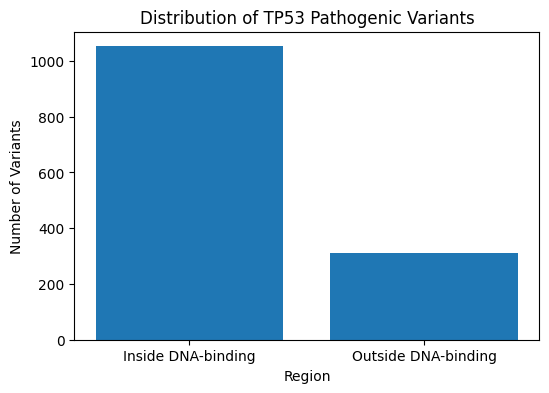

In [24]:
labels= ["Inside DNA-binding", "Outside DNA-binding"]
counts= [inside, outside]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)

plt.title("Distribution of TP53 Pathogenic Variants")
plt.xlabel("Region")
plt.ylabel("Number of Variants")

plt.show()

**Mutation Density**

In [25]:
inside=1052
outside= 311
domain_length= 191
outside_length= 202

inside_density= inside / domain_length
outside_density= outside / outside_length

print("Mutation density inside domain :", round(inside_density,2))
print("Mutation density outside domain:", round(outside_density,2))

Mutation density inside domain : 5.51
Mutation density outside domain: 1.54


**Protein Domain Architecture**

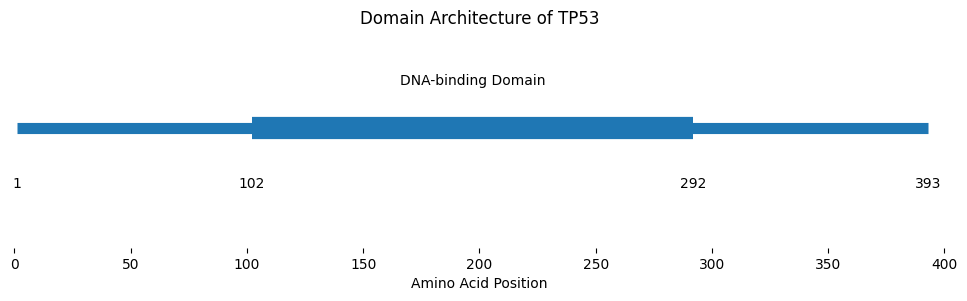

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,2.8))

# Whole protein
plt.hlines(y=1, xmin=1, xmax=393, linewidth=8)

# DNA-binding domain
plt.hlines(y=1, xmin=102, xmax=292, linewidth=16)

# Labels
plt.text(197, 1.18, "DNA-binding Domain", ha="center", fontsize=10)

# Position labels
plt.text(1, 0.75, "1", ha="center")
plt.text(102, 0.75, "102", ha="center")
plt.text(292, 0.75, "292", ha="center")
plt.text(393, 0.75, "393", ha="center")

plt.title("Domain Architecture of TP53")

plt.xlabel("Amino Acid Position")

plt.yticks([])

plt.xlim(0,400)
plt.ylim(0.5,1.4)

plt.box(False)

plt.show()